In [2]:
import torch
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.no_grad().__enter__()

os.environ["TOKENIZERS_PARALLELISM"] = "true"

print(f"Device: {device}")
print(device)

Device: cuda
cuda


In [ ]:
import torch.nn.functional as F
import math
from xpmir.text.huggingface import HFStringTokenizer, HFTokensEncoder
from xpmir.text.encoders import TokenizedTextEncoder
from xpmir.learning.optim import ModuleInitMode
from xpmir.models import AutoModel
from xpmir.text.huggingface import HFModel
from neural.tokenizer import HFStringTokenizerColBERT
from xpmir.neural.interaction.common import DotProductSimilarity
from neural.ColBERT import ColBERTEncoder, HFColBERTTokensEncoder, ColBERTProjectorAdapter, HFTokensEncoderNoType, HFTokensEncoderNoTypeTransform
from neural.sae import (
    SAESPLADE,
    FastTopKSAEAdapter, 
    SAESPLADETokenizedEncoder,
)
from xpmir.text.tokenizers import TokenizerOptions
from xpmir.text.huggingface import (
    HFTokenizer,
    HFTokenizerAdapter,
    HFMaskedLanguageModel,
)
from xpmir.neural.dual import DotDense
from xpmir.neural.splade import MaxAggregation, SpladeTextEncoderV2
from datamaestro_text.data.ir.base import (
    TopicRecord,
    DocumentRecord,
    ScoredItem,
    IDItem,
    create_record,
    TextItem
)
from xpmir.rankers import ScoredDocument
from tqdm import tqdm
from xpmir.text.adapters import TopicTextConverter
import numpy as np
import json
from pathlib import Path


In [ ]:
from analysis.load_model import *
import numpy as np
from xpmir.text.huggingface import HFTokenizer
from xpmir.neural.splade import MaxAggregation

### Instantiate models

storage_folder = "~/sae_models/"

MODELS_PATH = {
    "baseline": f"{storage_folder}/splade_distil/normal_k=8/19c62889253d135ab4b0ed5dce54fd8e6ce98e61d96443f78750a9193785c881/model.pth",
    "sae_with_transform_head": f"{storage_folder}/normal_base/26c841d9f85b65bdb218df0e18e0a1ef439d07cc95cbe460689cf4640959d63b/model.pth",
    "sae_wo_transform_head_layer_6": f"{storage_folder}/normal_base/bb52be8203455b954fdacb45b23db38acc3f26f86e7b23fee6b67148632053fa/model.pth",
    "sae_wo_transform_head_layer_5": f"{storage_folder}/normal_base/554b89d2f3f34dfa16cecfd76a943eeaf7ac64b8982ceed99658f9e0d4cafb76/model.pth",
    "sae_wo_transform_head_layer_4": f"{storage_folder}/normal_base/dcadfa6d88341c63617e78ba34cd00a8ac502afaaf89a40ae4374c150372c66e/model.pth",
    "sae_wo_transform_head_layer_3": f"{storage_folder}/normal_base/343849fbe8960a2b5e372be8d801c9800cbdb11cd145886a1f831941db747a27/model.pth"
}

baseline_splade = load_baseline(MODELS_PATH["baseline"], k=8, device=device)
sae_splade = load_sae_without_transform_head(MODELS_PATH["sae_wo_transform_head_layer_6"], k=8, sae_width=65536, override_k=8, dead_steps_threshold=10_000_000, layer=-1, device=device)


In [ ]:
### OTHER BASELINE CHECKPOINT ###
from neural.sae.model import SPLADEEncoder

k=8
model_id = "distilbert/distilbert-base-uncased"

converter = TopicTextConverter.C()
tokenizer = HFTokenizer.C(model_id=model_id)
aggregation = MaxAggregation.C()
base_encoder = HFMaskedLanguageModel.from_pretrained_id(model_id)
doc_tokenizer_col = HFStringTokenizerColBERT.from_pretrained_id(
    model_id,
    query=False,
    num_add_tokens=1,
    converter=converter,
)
qry_tokenizer_col = HFStringTokenizerColBERT.from_pretrained_id(
    model_id,
    query=True,
    converter=converter,
)
# the base encoder from huggingface
base_encoder = HFMaskedLanguageModel.from_pretrained_id(
    model_id
)

splade_document_encoder = SPLADEEncoder.C(
    tokenizer=doc_tokenizer_col,
    encoder=base_encoder,
    length=256,
    mask_punctuation=False,
    override_k=k,
)
splade_query_encoder = SPLADEEncoder.C(
    tokenizer=qry_tokenizer_col,
    encoder=base_encoder,
    length=32,
    mask_punctuation=False,
    override_k=k,
)
# we don't scale the tradtional splade model
baseline_splade = (
    SAESPLADE.C(
        encoder=splade_document_encoder,
        query_encoder=splade_query_encoder,
        scale=False,
    ).instance()
)

## Load code
splade_baseline_cp = torch.load("/path/to/baseline_splade.pth")

baseline_splade.initialize(ModuleInitMode.DEFAULT.to_options())
baseline_splade.load_state_dict(splade_baseline_cp)
baseline_splade.to(device).eval()

In [ ]:
# # ### SECOND AND THIRD CHECKPOINTS ###

model_id = "distilbert/distilbert-base-uncased"
k=8
sae_width=65536
override_k=8 # TODO: it depends on how many latents a token activate at most in SPLADE
dead_steps_threshold=10_000_000

# tokenizers
converter = TopicTextConverter.C()
document_tokenizer = HFStringTokenizerColBERT.from_pretrained_id(model_id, query=False, num_add_tokens=1, converter=converter)
query_tokenizer = HFStringTokenizerColBERT.from_pretrained_id(model_id, query=True, converter=converter)
base_encoder = HFModel.from_pretrained_id(model_id)
text_base_encoder = HFTokensEncoderNoType.C(model=base_encoder)

document_token_encoder = FastTopKSAEAdapter.C(
    model=text_base_encoder,
    sae_width=sae_width,
    k=k,
    aux_k=k*2,
    dead_steps_threshold=dead_steps_threshold,
    normalize=False
)

colbert_document_encoder: SAESPLADETokenizedEncoder = SAESPLADETokenizedEncoder.C(
    tokenizer=document_tokenizer,
    encoder=document_token_encoder,
    length=256,
    mask_punctuation=False,
    override_k=override_k,
    aggregation="amax",
)
colbert_query_encoder: SAESPLADETokenizedEncoder = SAESPLADETokenizedEncoder.C(
    tokenizer=query_tokenizer,
    encoder=document_token_encoder,
    length=32,
    mask_punctuation=False,
    override_k=override_k,
    aggregation="amax",
)

splade: SAESPLADE = SAESPLADE.C(
    encoder=colbert_document_encoder,
    query_encoder=colbert_query_encoder,
    scale=True,
).instance()

# the model trained with k = 8
sae_splade = torch.load("/path/to/sae.pth")

splade.initialize(ModuleInitMode.DEFAULT.to_options())
splade.load_state_dict(sae_splade)

splade.to(device).eval()

In [ ]:
from datamaestro import prepare_dataset
from xpmir.learning.devices import Device, CudaDevice
from xpmir.learning.base import Random
from xpmir.documents.samplers import RandomDocumentSampler

random = Random.C(seed=12)
documents = prepare_dataset("irds.msmarco-passage.documents")

# random text example
d_sampler=RandomDocumentSampler.C(
    documents=documents,
    max_count=10_000,
    random=random,
).instance()
_, doc_iter = d_sampler()
d_records = [record for record in doc_iter]

with torch.no_grad():
    batch_size = 32
    baseline_doc_aggregated = []
    doc_aggregated = []
    for i in tqdm(range(0, len(d_records), batch_size)):
        batch = d_records[i:i+batch_size]
        baseline_doc_aggregated.append(baseline_splade.encode_documents(batch).value.cpu().numpy())
        doc_aggregated.append(splade.encode_documents(batch).value.cpu().numpy())
    baseline_doc_aggregated = np.concatenate(baseline_doc_aggregated, axis=0)
    doc_aggregated = np.concatenate(doc_aggregated, axis=0)
    

In [96]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
idx_list = []
k = 20

for idx, record in enumerate(baseline_doc_aggregated):
    # indices of positive values
    pos = np.flatnonzero(record > 0)
    if pos.size == 0:
        token_indices = np.array([], dtype=np.int64)
    elif pos.size <= k:
        token_indices = pos[np.argsort(record[pos])[::-1]]
    else:
        # take top-k by value (fast)
        topk = np.argpartition(record, -k)[-k:]
        token_indices = topk[np.argsort(record[topk])[::-1]]
        text_tokens = tokenizer.convert_ids_to_tokens(token_indices)
        if "bank" in text_tokens or "banks" in text_tokens:
            print(idx, d_records[idx][TextItem].text)
            idx_list.append(idx)

281 Treasury said that it and the Federal Reserve Bank of New York provided a total $182.3 billion to AIG, which paid back a total $205 billion, for a total positive return, or profit, to the government of $22.7 billion. In addition, AIG sold off a number of its own assets to raise money to pay back the government.
298 1 The Bank was founded in 1934 as a privately owned corporation. 2  In 1938, the Bank became a Crown corporation belonging to the federal government. 3  Since that time, the Minister of Finance has held the entire share capital issued by the Bank.
412 Roslyn Savings Bank. Established in 1875, The Roslyn Savings Bank was the first financial institution headquartered in Nassau County, one of two counties--with Suffolk--that constitute Long Island, New York.
672 In the clip, Banks portrays a sassy real estate-obsessed version of herself who is observing a real estate buyer named Jim Bob as he browses Realtor.com.
766 Longer hours, now longer-er. We're open longer than any o

In [97]:
# target_latents = set([3694, 35332, 37550, 44981, 48757, 58125, 58491, 65177]) # Links, 4957
# target_latents = set([2539, 5648, 6116, 7462, 11136, 13279, 17476, 18137, 21825, 22626, 26144, 26745, 32112, 33948, 40193, 42118, 45167, 47594, 53067, 55215, 60420]) # football
target_latents = set([9394, 23304, 43052, 44077] + [5391, 55773, 62508]) # bank, 2924 + banks, 5085
# target_latents = [5162, 48743, 5162] # spring, 3500 + springs, 6076

latents_to_text = {latent: [] for latent in target_latents}

for position, (saes, tokens) in enumerate(zip(doc_aggregated[idx_list], baseline_doc_aggregated[idx_list])):
    sae_indices = np.where(saes > 0)[0]
    token_indices = np.where(tokens > 0)[0]
    overlap = set(sae_indices).intersection(target_latents)
    if (2924 in token_indices or 5085 in token_indices) and overlap:
        for latent in overlap:
            latents_to_text[latent].append(d_records[idx_list[position]][TextItem].text)
        print(position, d_records[idx_list[position]][TextItem].text, overlap)
        print("-----")

0 Treasury said that it and the Federal Reserve Bank of New York provided a total $182.3 billion to AIG, which paid back a total $205 billion, for a total positive return, or profit, to the government of $22.7 billion. In addition, AIG sold off a number of its own assets to raise money to pay back the government. {9394, 43052}
-----
1 1 The Bank was founded in 1934 as a privately owned corporation. 2  In 1938, the Bank became a Crown corporation belonging to the federal government. 3  Since that time, the Minister of Finance has held the entire share capital issued by the Bank. {23304, 9394, 43052}
-----
2 Roslyn Savings Bank. Established in 1875, The Roslyn Savings Bank was the first financial institution headquartered in Nassau County, one of two counties--with Suffolk--that constitute Long Island, New York. {9394, 43052}
-----
3 In the clip, Banks portrays a sassy real estate-obsessed version of herself who is observing a real estate buyer named Jim Bob as he browses Realtor.com. {4

In [98]:
# convert dict to DataFrame (one row per latent, texts as list) and save
import pandas as pd
df_latents = pd.DataFrame({
    'latent_id': list(latents_to_text.keys()),
    'texts': list(latents_to_text.values())
})
df_latents.to_csv('/home/vast/tree_colbert/Results/bank_polysemantic.csv', index=False)
df_latents.head()

,latent_id,texts
0,23304,[1 The Bank was founded in 1934 as a privately...
1,43052,[Treasury said that it and the Federal Reserve...
2,44077,"[Longer hours, now longer-er. We're open longe..."
3,62508,"[In the clip, Banks portrays a sassy real esta..."
4,5391,[Chase bank routing number is valid within the...


In [9]:
co_occurences = np.zeros((baseline_doc_aggregated.shape[1], doc_aggregated.shape[1]), dtype=np.int32)
baseline_splade_count_appearances = np.zeros(baseline_doc_aggregated.shape[1], dtype=np.int32)
splade_count_appearances = np.zeros(doc_aggregated.shape[1], dtype=np.int32)

for b_vec, s_vec in zip(baseline_doc_aggregated, doc_aggregated):
    b_indices = np.where(b_vec > 0)[0]
    s_indices = np.where(s_vec > 0)[0]
    for b_idx in b_indices:
        baseline_splade_count_appearances[b_idx] += 1
        for s_idx in s_indices:
            co_occurences[b_idx, s_idx] += 1

    for s_idx in s_indices:
        splade_count_appearances[s_idx] += 1

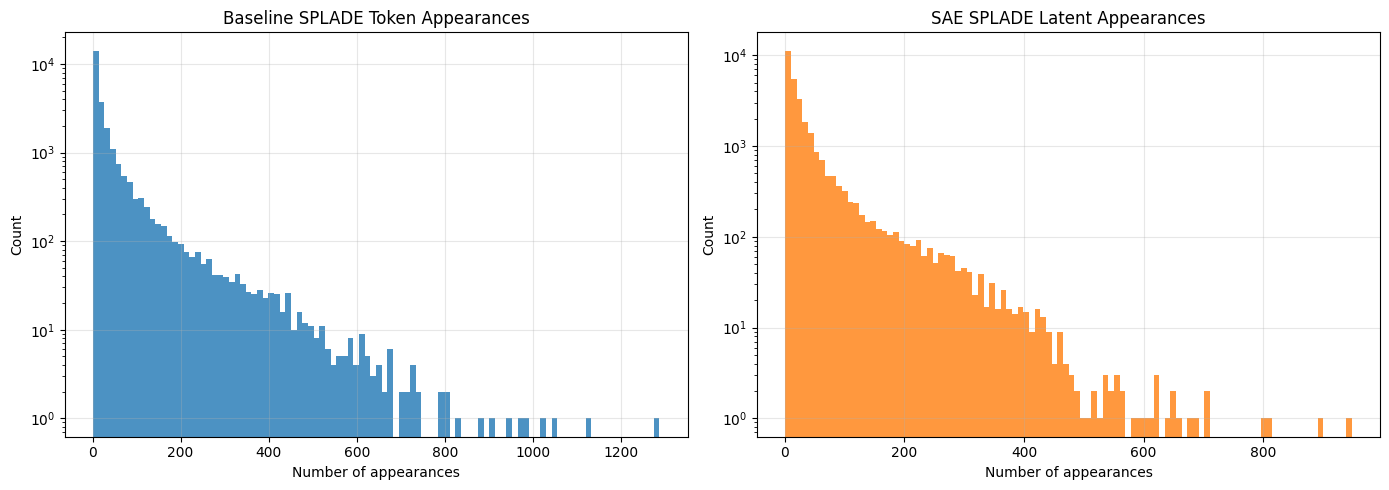

Baseline SPLADE - Total tokens with appearances > 5: 16535
Baseline SPLADE - Max appearances: 1287
Baseline SPLADE - Mean appearances (non-zero): 54.07

SAE SPLADE - Total latents with appearances > 5: 22274
SAE SPLADE - Max appearances: 948
SAE SPLADE - Mean appearances (non-zero): 48.25


In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for baseline SPLADE token appearances
axs[0].hist(baseline_splade_count_appearances[baseline_splade_count_appearances > 0], bins=100, color='C0', alpha=0.8)
axs[0].set_title('Baseline SPLADE Token Appearances')
axs[0].set_xlabel('Number of appearances')
axs[0].set_ylabel('Count')
axs[0].set_yscale('log')
axs[0].grid(True, alpha=0.3)

# Histogram for SAE SPLADE latent appearances
axs[1].hist(splade_count_appearances[splade_count_appearances > 0], bins=100, color='C1', alpha=0.8)
axs[1].set_title('SAE SPLADE Latent Appearances')
axs[1].set_xlabel('Number of appearances')
axs[1].set_ylabel('Count')
axs[1].set_yscale('log')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Baseline SPLADE - Total tokens with appearances > 5: {(baseline_splade_count_appearances > 5).sum()}")
print(f"Baseline SPLADE - Max appearances: {baseline_splade_count_appearances.max()}")
print(f"Baseline SPLADE - Mean appearances (non-zero): {baseline_splade_count_appearances[baseline_splade_count_appearances > 5].mean():.2f}")
print(f"\nSAE SPLADE - Total latents with appearances > 5: {(splade_count_appearances > 5).sum()}")
print(f"SAE SPLADE - Max appearances: {splade_count_appearances.max()}")
print(f"SAE SPLADE - Mean appearances (non-zero): {splade_count_appearances[splade_count_appearances > 5].mean():.2f}")

In [11]:
k = 5  # start with k = 5

# build boolean masks for tokens (rows) and latents (cols)
token_mask = (baseline_splade_count_appearances >= k)
latent_mask = (splade_count_appearances >= k)

# filtered count vectors (keep as numpy arrays)
baseline_filtered = baseline_splade_count_appearances[token_mask]
sae_filtered = splade_count_appearances[latent_mask]

# adapt co-occurrence matrix by removing rows/cols below threshold
co_occ_filtered = co_occurences[np.ix_(token_mask, latent_mask)]

# info
print(f"k = {k}")
print(f"Original tokens: {co_occurences.shape[0]}, kept: {token_mask.sum()}")
print(f"Original latents: {co_occurences.shape[1]}, kept: {latent_mask.sum()}")
print(f"Filtered co-occurrence shape: {co_occ_filtered.shape}")

print("Baseline SPLADE - Max appearances:", baseline_filtered.max())
print("Baseline SPLADE - Mean appearances:", baseline_filtered.mean())
print("SAE SPLADE - Max appearances:", sae_filtered.max())
print("SAE SPLADE - Mean appearances:", sae_filtered.mean())

k = 5
Original tokens: 30522, kept: 17674
Original latents: 65536, kept: 23340
Filtered co-occurrence shape: (17674, 23340)
Baseline SPLADE - Max appearances: 1287
Baseline SPLADE - Mean appearances: 50.90613330315718
SAE SPLADE - Max appearances: 948
SAE SPLADE - Mean appearances: 46.272707797772064


In [14]:
### Get the average estimator of the appearance of tokens (resp. latents) given latents (resp. tokens)
conditional_probas_of_latents_given_token = np.zeros_like(co_occ_filtered, dtype=np.float32) # To get this we divide each row of the co-occurence matrix by the nb of apparations of the corresponding token
for i in range(co_occ_filtered.shape[0]):
    if baseline_filtered[i] > 0:
        if co_occ_filtered[i].max() > baseline_filtered[i]:
            print(i, co_occ_filtered[i].max(), baseline_filtered[i])
        conditional_probas_of_latents_given_token[i] = co_occ_filtered[i] / baseline_filtered[i]

conditional_probas_of_tokens_given_latents = np.zeros_like(co_occ_filtered, dtype=np.float32) # To get this we divide each column of the co-occurence matrix by the nb of apparations of the corresponding latent
for j in range(co_occ_filtered.shape[1]):
    if sae_filtered[j] > 0:
        conditional_probas_of_tokens_given_latents[:, j] = co_occ_filtered[:, j] / sae_filtered[j]

In [15]:
baseline_splade_probas = baseline_filtered / 10_000
sae_splade_probas = sae_filtered / 10_000

# conditional_probas_of_latents_given_token_minus_sae_splade_probas = conditional_probas_of_latents_given_token -  sae_splade_probas[np.newaxis, :]
# conditional_probas_of_tokens_given_latents_minus_baseline_splade_probas = conditional_probas_of_tokens_given_latents - baseline_splade_probas[:, np.newaxis] 

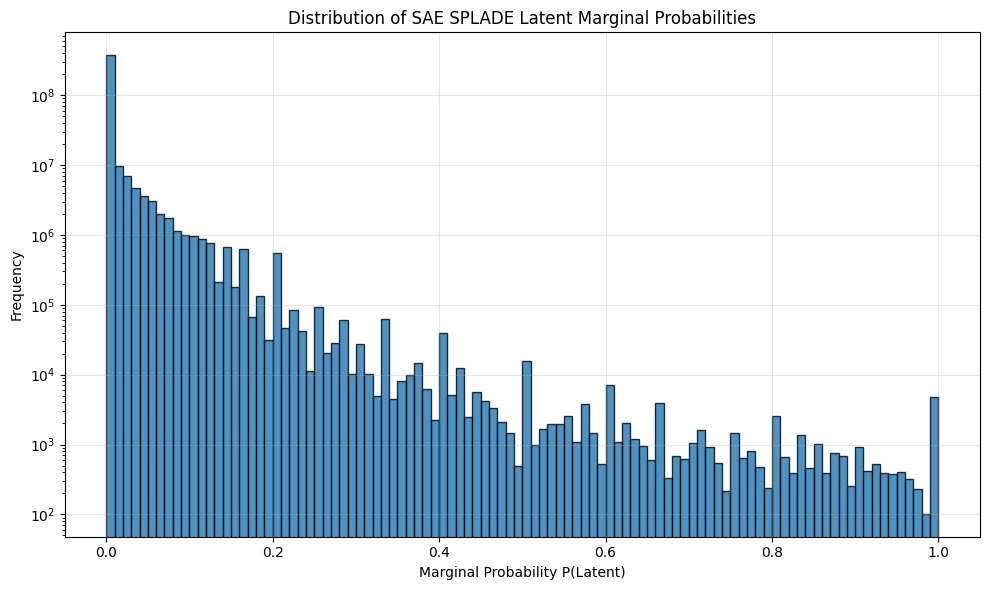

Min probability: 0.000000
Max probability: 1.000000
Mean probability: 0.005433
Median probability: 0.000000
Total latents: 412511160


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(conditional_probas_of_tokens_given_latents.flatten(), bins=100, alpha=0.8, edgecolor='black')
plt.xlabel('Marginal Probability P(Latent)')
plt.ylabel('Frequency')
plt.title('Distribution of SAE SPLADE Latent Marginal Probabilities')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Min probability: {conditional_probas_of_tokens_given_latents.flatten().min():.6f}")
print(f"Max probability: {conditional_probas_of_tokens_given_latents.flatten().max():.6f}")
print(f"Mean probability: {conditional_probas_of_tokens_given_latents.flatten().mean():.6f}")
print(f"Median probability: {np.median(conditional_probas_of_tokens_given_latents.flatten()):.6f}")
print(f"Total latents: {len(conditional_probas_of_tokens_given_latents.flatten())}")

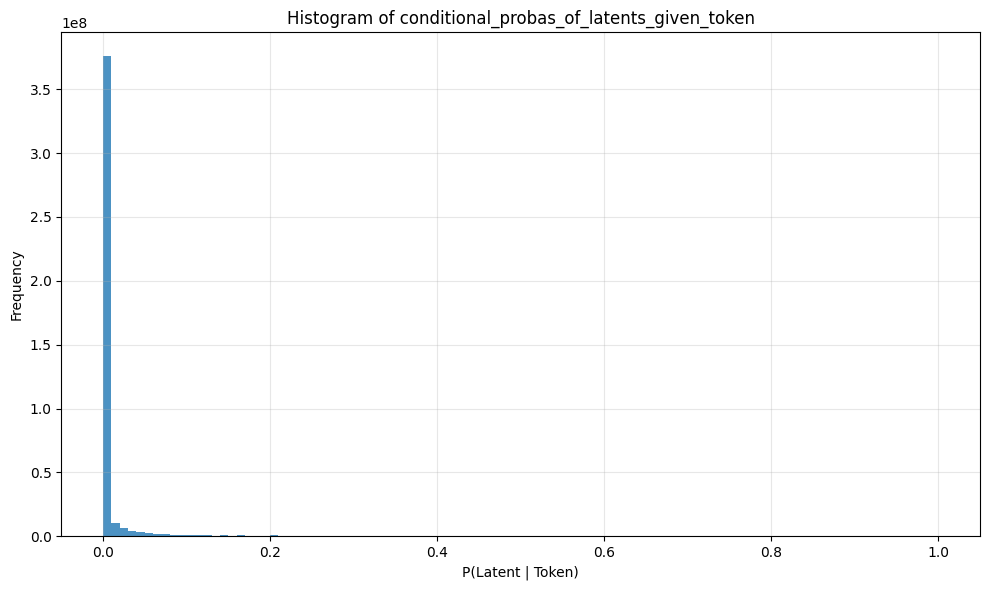

Min: 0.0000
Max: 1.0000
Mean: 0.0050
Median: 0.0000
Non-zero values: 50329552


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(conditional_probas_of_latents_given_token.flatten(), bins=100, alpha=0.8)
plt.xlabel('P(Latent | Token)')
plt.ylabel('Frequency')
plt.title('Histogram of conditional_probas_of_latents_given_token')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some statistics
values = conditional_probas_of_latents_given_token.flatten()
print(f"Min: {values.min():.4f}")
print(f"Max: {values.max():.4f}")
print(f"Mean: {values.mean():.4f}")
print(f"Median: {np.median(values):.4f}")
print(f"Non-zero values: {(values != 0).sum()}")

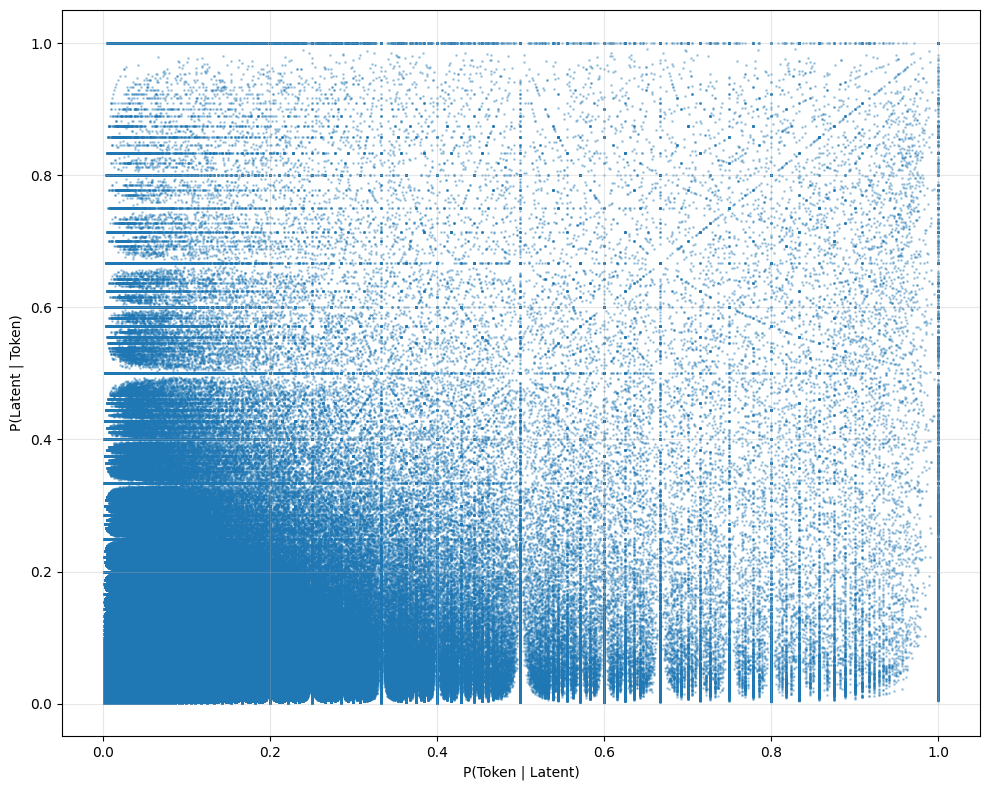

Total pairs plotted: 50329552
Max P(Token|Latent): 1.0000
Max P(Latent|Token): 1.0000


In [19]:
import matplotlib.pyplot as plt

# Create scatter plot using conditional probabilities
plt.figure(figsize=(10, 8))

# Flatten the matrices to get all pairs
x_data = conditional_probas_of_tokens_given_latents.flatten()
y_data = conditional_probas_of_latents_given_token.flatten()

# Filter out zero pairs for better visualization
non_zero_mask = (x_data > 0) | (y_data > 0)
x_filtered = x_data[non_zero_mask]
y_filtered = y_data[non_zero_mask]

plt.scatter(x_filtered, y_filtered, alpha=0.3, s=1)
plt.xlabel('P(Token | Latent)')
plt.ylabel('P(Latent | Token)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total pairs plotted: {len(x_filtered)}")
print(f"Max P(Token|Latent): {x_filtered.max():.4f}")
print(f"Max P(Latent|Token): {y_filtered.max():.4f}")

## Binomial tests: latent|token and token|latent
Run binomial tests on each pair (observed co-occurrences vs marginal expectation).
The test for `P(latent | token)` uses successes=`C[i,j]`, trials=`count_token[i]`, p=`P(latent)`;
the test for `P(token | latent)` mirrors this with roles swapped. Results are BH-corrected.

In [20]:
# Fast vectorized binomial p-values using scipy.stats.binom
import numpy as np
from scipy.stats import binom
# choose co-occurrence matrix and count vectors (prefer filtered/pruned versions if available)
C = co_occ_filtered if 'co_occ_filtered' in globals() else (co_occurences if 'co_occurences' in globals() else None)
if C is None:
    raise RuntimeError('No co-occurrence matrix found in the notebook namespace')

count_tokens = np.asarray(baseline_filtered) if 'baseline_filtered' in globals() else np.asarray(baseline_splade_count_appearances)
count_latents = np.asarray(sae_filtered) if 'sae_filtered' in globals() else np.asarray(splade_count_appearances)

# marginal probabilities (use normalized saved vectors if present)
if 'baseline_splade_probas' in globals():
    p_token = np.asarray(baseline_splade_probas)
else:
    N = float(doc_aggregated.shape[0]) if 'doc_aggregated' in globals() else float(np.maximum(1.0, C.sum()))
    p_token = count_tokens / N

if 'sae_splade_probas' in globals():
    p_latent = np.asarray(sae_splade_probas)
else:
    N = float(doc_aggregated.shape[0]) if 'doc_aggregated' in globals() else float(np.maximum(1.0, C.sum()))
    p_latent = count_latents / N

# ensure shapes align (C is token x latent)
T, L = C.shape
if len(count_tokens) < T or len(count_latents) < L:
    print('Warning: count vectors shorter than co-occurrence dims; attempting to proceed')

# Vectorized two-sided p-value approximation: two-sided = 2 * min(P(X<=k), P(X>=k))
# P(latent | token): trials = count_tokens (per row), p = p_latent (per column)
n_rows = count_tokens.reshape(-1, 1).astype(int)
p_cols = p_latent.reshape(1, -1)
k_mat = C.astype(int)

# compute upper tail P(X >= k) = sf(k-1)
upper = binom.sf(k_mat - 1, n_rows, p_cols)
lower = binom.cdf(k_mat, n_rows, p_cols)
pvals_lat_given_token = 2.0 * np.minimum(upper, lower)
pvals_lat_given_token = np.clip(pvals_lat_given_token, 0.0, 1.0)
# set p-value to 1 where trials == 0 to avoid NaNs
pvals_lat_given_token = np.where(n_rows > 0, pvals_lat_given_token, 1.0)



In [21]:
# Vectorized computation for P(token | latent): trials = count_latents (per column), p = p_token (per row)
n_cols = count_latents.reshape(1, -1).astype(int)
p_rows = p_token.reshape(-1, 1)
# compute upper and lower tails with broadcasting
upper2 = binom.sf(k_mat - 1, n_cols, p_rows)
lower2 = binom.cdf(k_mat, n_cols, p_rows)
pvals_token_given_latent = 2.0 * np.minimum(upper2, lower2)
pvals_token_given_latent = np.clip(pvals_token_given_latent, 0.0, 1.0)
# set p-value to 1 where trials == 0
pvals_token_given_latent = np.where(n_cols > 0, pvals_token_given_latent, 1.0)

In [22]:
# Benjamini-Hochberg FDR correction (vectorized)
def bh_adjust(pvals):
    p = np.asarray(pvals, dtype=float).flatten()
    m = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    denom = np.arange(1, m + 1)
    q = p_sorted * m / denom
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    adj = np.empty_like(q)
    adj[order.argsort()] = q
    return adj.reshape(pvals.shape)

adj_lat_given_token = bh_adjust(pvals_lat_given_token)
adj_token_given_latent = bh_adjust(pvals_token_given_latent)

alpha = 0.05
sig_lat_given_token = pvals_lat_given_token < alpha
sig_token_given_latent = pvals_token_given_latent < alpha

In [23]:
# Save results for downstream analysis
np.save('pvals_lat_given_token_more_recent.npy', pvals_lat_given_token)
np.save('pvals_token_given_latent_more_recent.npy', pvals_token_given_latent)
np.save('adj_pvals_lat_given_token_more_recent.npy', adj_lat_given_token)
np.save('adj_pvals_token_given_latent_more_recent.npy', adj_token_given_latent)
print('Saved p-value matrices to .npy files')

Saved p-value matrices to .npy files


In [24]:
# helper to report top-k smallest p-values with context (token/latent original ids and optional strings)
import pandas as pd
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def top_k_pairs(pvals, C, counts_rows, counts_cols, p_marg_cols, token_map=None, latent_map=None, tokenizer_obj=None, k=50):
    flat_idx = np.argsort(pvals.flatten())[:k]
    rows, cols = np.unravel_index(flat_idx, pvals.shape)
    out = []
    for r, c in zip(rows, cols):
        pval = float(pvals[r, c])
        k_success = int(C[r, c])
        n = int(counts_rows[r]) if counts_rows is not None else None
        obs = (k_success / n) if (n is not None and n > 0) else np.nan
        expect = float(p_marg_cols[c])
        token_orig = int(token_map[r]) if token_map is not None else int(r)
        latent_orig = int(latent_map[c]) if latent_map is not None else int(c)
        token_str = None
        if tokenizer_obj is not None:
            try:
                token_str = tokenizer_obj.convert_ids_to_tokens(token_orig)
            except Exception:
                token_str = None
        out.append((pval, token_orig, token_str, latent_orig, k_success, n, obs, expect))
    df = pd.DataFrame(out, columns=['pval','token_id','token_str','latent_id','k','n','obs_rate','expect_p'])
    return df

token_map = token_indices_tracking if 'token_indices_tracking' in globals() else np.arange(T)
latent_map = latent_indices_tracking if 'latent_indices_tracking' in globals() else np.arange(L)

print('\nTop pairs for P(latent | token) by smallest raw p-value:')
df_lat_given_token = top_k_pairs(pvals_lat_given_token, C, count_tokens, count_latents, p_latent, token_map, latent_map, tokenizer, k=50)
display(df_lat_given_token)

print('\nTop pairs for P(token | latent) by smallest raw p-value:')
df_token_given_latent = top_k_pairs(pvals_token_given_latent, C, count_tokens, count_latents, p_latent, token_map, latent_map, tokenizer, k=50)
display(df_token_given_latent)


Top pairs for P(latent | token) by smallest raw p-value:


,pval,token_id,token_str,latent_id,k,n,obs_rate,expect_p
0,0.0,3867,percent,2318,372,391,0.951407,0.0444
1,0.0,3574,meaning,62255,441,626,0.704473,0.0680
2,0.0,2691,common,38053,356,406,0.876847,0.0369
3,0.0,2001,was,249,839,949,0.884089,0.0948
4,0.0,2047,new,61410,425,522,0.814176,0.0442
5,0.0,4785,climate,54146,282,344,0.819767,0.0400
6,0.0,7408,fee,11972,422,612,0.689542,0.0614
7,0.0,2067,back,42474,246,303,0.811881,0.0253
8,0.0,2171,name,39946,388,618,0.627832,0.0397
9,0.0,2491,control,22650,200,233,0.858369,0.0206



Top pairs for P(token | latent) by smallest raw p-value:


,pval,token_id,token_str,latent_id,k,n,obs_rate,expect_p
0,0.0,2740,health,56619,274,342,0.801170,0.0281
1,0.0,2689,change,7592,363,528,0.687500,0.0395
2,0.0,3609,color,50085,357,468,0.762821,0.0369
3,0.0,2326,service,34090,259,331,0.782477,0.0296
4,0.0,2047,new,61410,425,522,0.814176,0.0442
5,0.0,2482,car,60049,328,436,0.752294,0.0374
6,0.0,3058,date,26802,459,717,0.640167,0.0515
7,0.0,2342,need,59609,432,675,0.640000,0.0461
8,0.0,7408,fee,15197,359,612,0.586601,0.0435
9,0.0,2191,make,29951,359,680,0.527941,0.0427


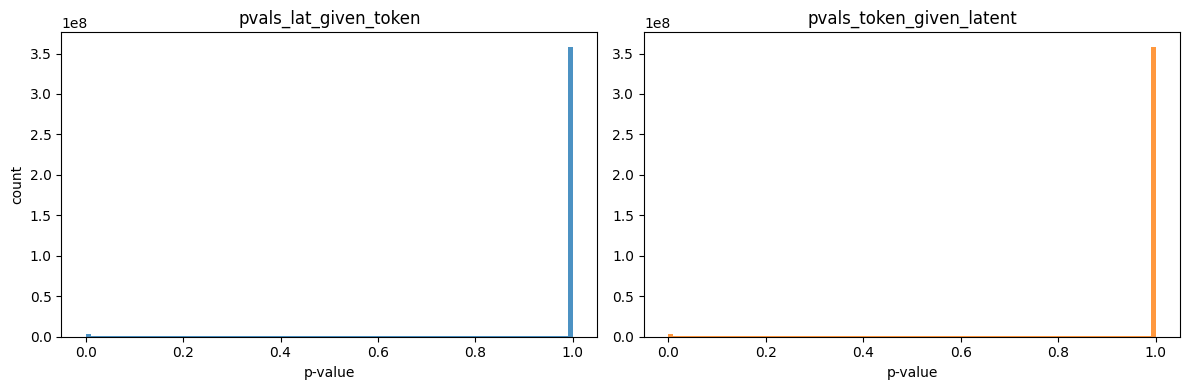

In [25]:
import matplotlib.pyplot as plt
import numpy as np

p1 = np.ravel(pvals_lat_given_token)
p2 = np.ravel(pvals_token_given_latent)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(p1, bins=100, range=(0, 1), color='C0', alpha=0.8)
axs[0].set_title('pvals_lat_given_token')
axs[0].set_xlabel('p-value'); axs[0].set_ylabel('count')

axs[1].hist(p2, bins=100, range=(0, 1), color='C1', alpha=0.8)
axs[1].set_title('pvals_token_given_latent')
axs[1].set_xlabel('p-value')

plt.tight_layout()
plt.show()

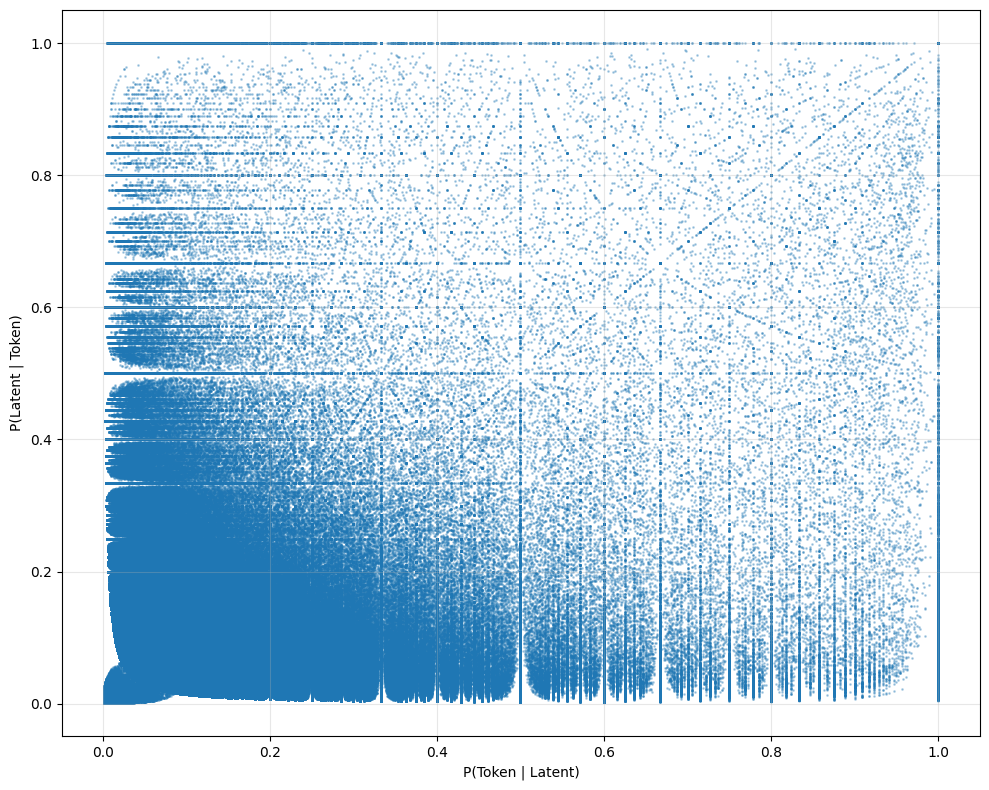

Total pairs plotted (non-zero & sig_any): 7253248
Pairs non-zero before filtering: 50329552
Pairs significant in at least one test: 7629385


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the matrices to get all pairs
x_data = conditional_probas_of_tokens_given_latents.flatten()
y_data = conditional_probas_of_latents_given_token.flatten()

# mask non-zero for visualization
non_zero_mask = (x_data > 0) | (y_data > 0)

# keep only pairs where at least one binomial test is significant (BH-adjusted masks)
# sig_lat_given_token and sig_token_given_latent are boolean arrays shaped like the p-value matrices
sig_any = (sig_lat_given_token | sig_token_given_latent).flatten()

# final keep mask: non-zero AND at least one significant
keep_mask = non_zero_mask & sig_any

x_filtered = x_data[keep_mask]
y_filtered = y_data[keep_mask]

plt.figure(figsize=(10, 8))
plt.scatter(x_filtered, y_filtered, alpha=0.3, s=1)
plt.xlabel('P(Token | Latent)')
plt.ylabel('P(Latent | Token)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total pairs plotted (non-zero & sig_any): {len(x_filtered)}")
print(f"Pairs non-zero before filtering: {non_zero_mask.sum()}")
print(f"Pairs significant in at least one test: {sig_any.sum()}")

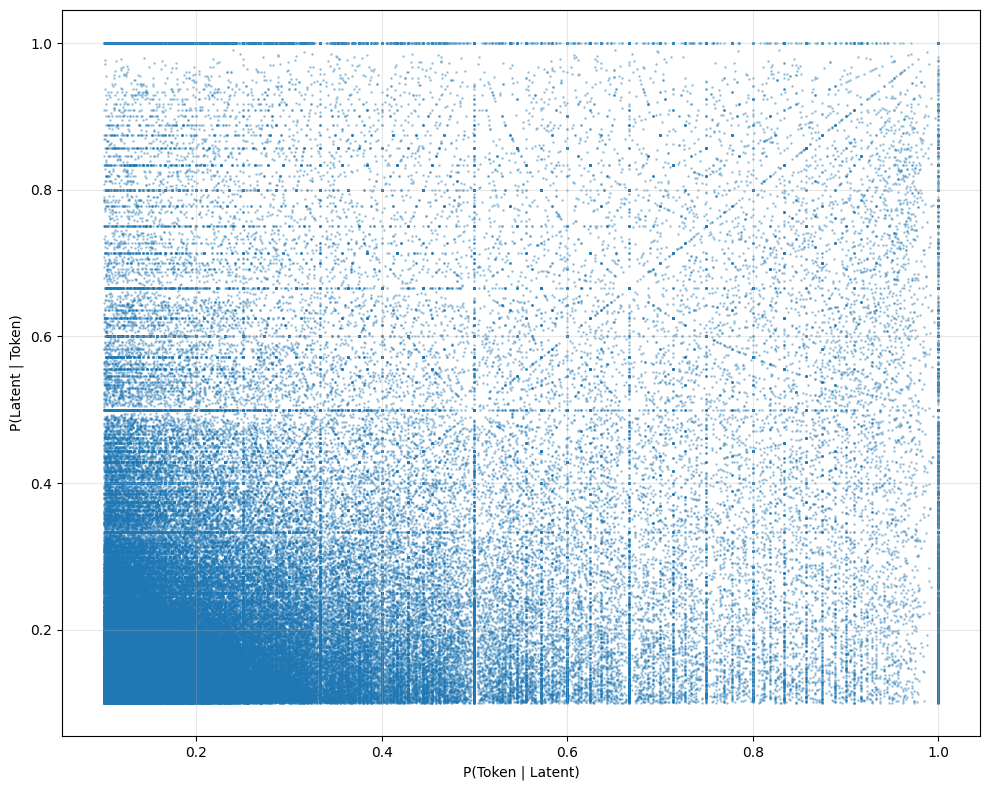

Total pairs plotted (non-zero & sig_any): 357374
Pairs non-zero before filtering: 357375
Pairs significant in at least one test: 7629385


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the matrices to get all pairs
x_data = conditional_probas_of_tokens_given_latents.flatten()
y_data = conditional_probas_of_latents_given_token.flatten()

# mask non-zero for visualization
non_zero_mask = (x_data > 0.1) & (y_data > 0.1)

# keep only pairs where at least one binomial test is significant (BH-adjusted masks)
# sig_lat_given_token and sig_token_given_latent are boolean arrays shaped like the p-value matrices
sig_any = (sig_lat_given_token | sig_token_given_latent).flatten()

# final keep mask: non-zero AND at least one significant
keep_mask = non_zero_mask & sig_any

x_filtered = x_data[keep_mask]
y_filtered = y_data[keep_mask]

plt.figure(figsize=(10, 8))
plt.scatter(x_filtered, y_filtered, alpha=0.3, s=1)
plt.xlabel('P(Token | Latent)')
plt.ylabel('P(Latent | Token)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total pairs plotted (non-zero & sig_any): {len(x_filtered)}")
print(f"Pairs non-zero before filtering: {non_zero_mask.sum()}")
print(f"Pairs significant in at least one test: {sig_any.sum()}")

In [28]:
FILTERS = {
    "non_zero_mask": (x_data > 0) | (y_data > 0),
    "above_0.1": (x_data > 0.1) & (y_data > 0.1),
}

In [29]:
x_data = conditional_probas_of_tokens_given_latents.flatten()
y_data = conditional_probas_of_latents_given_token.flatten()

mask  = FILTERS["above_0.1"]
sig_any = (sig_lat_given_token | sig_token_given_latent).flatten()
keep_mask = mask & sig_any

x_keep = x_data[keep_mask]
y_keep = y_data[keep_mask]

area1 = (x_keep <= 0.4) & (y_keep >= 0.6)
area2 = (x_keep >= 0.6) & (y_keep <= 0.4)
area3 = (x_keep >= 0.6) & (y_keep >= 0.6)

n1 = int(area1.sum())
n2 = int(area2.sum())
n3 = int(area3.sum())
total = int(x_keep.size)

print(f"Total kept points: {total}")
print(f"Area1 (x <= 0.2 & y >= 0.8): {n1}")
print(f"Area2 (x >= 0.8 & y <= 0.2): {n2}")
print(f"Area3 (x >= 0.8 & y >= 0.8): {n3}")

Total kept points: 357374
Area1 (x <= 0.2 & y >= 0.8): 8283
Area2 (x >= 0.8 & y <= 0.2): 10655
Area3 (x >= 0.8 & y >= 0.8): 4743


In [30]:
import pandas as pd
import numpy as np

# flatten diffs and masks (use the "both significant" filter)
x = conditional_probas_of_tokens_given_latents.flatten()
y = conditional_probas_of_latents_given_token.flatten()

mask  = FILTERS["above_0.1"]

sig_any = (sig_lat_given_token | sig_token_given_latent).flatten()
keep = mask & sig_any

# get flat indices and row/col in C
flat_idx = np.where(keep)[0]
rows, cols = np.unravel_index(flat_idx, C.shape)

# ensure maps/fallbacks
token_map = token_indices_tracking if 'token_indices_tracking' in globals() else np.arange(C.shape[0])
latent_map = latent_indices_tracking if 'latent_indices_tracking' in globals() else np.arange(C.shape[1])

# helper to build dataframe rows
def build_rows(sel):
    out = []
    for r, c in zip(rows[sel], cols[sel]):
        tok_orig = int(token_map[r]) if token_map is not None else int(r)
        lat_orig = int(latent_map[c]) if latent_map is not None else int(c)
        try:
            tok_str = tokenizer.convert_ids_to_tokens(tok_orig) if 'tokenizer' in globals() else None
        except Exception:
            tok_str = None
        out.append({
            'row_idx': int(r),
            'col_idx': int(c),
            'token_id': tok_orig,
            'token_str': tok_str,
            'latent_id': lat_orig,
            'k': int(C[r, c]),
            'n_token': int(count_tokens[r]),
            'n_latent': int(count_latents[c]),
            'p_token_marg': float(p_token[r]),
            'p_latent_marg': float(p_latent[c]),
            'P_latent_given_token': float(conditional_probas_of_latents_given_token[r, c]),
            'P_token_given_latent': float(conditional_probas_of_tokens_given_latents[r, c]),
            'pval_lat_given_token': float(pvals_lat_given_token[r, c]),
            'pval_token_given_latent': float(pvals_token_given_latent[r, c]),
        })
    return out

# area selectors on kept points
x_keep = x[flat_idx]
y_keep = y[flat_idx]

area1_sel = (x_keep <= 0.4) & (y_keep >= 0.6)   # x small, y large
area2_sel = (x_keep >= 0.6) & (y_keep <= 0.4)   # x large, y small
area3_sel = (x_keep >= 0.6) & (y_keep >= 0.6)   # both large

df_area1 = pd.DataFrame(build_rows(area1_sel))
df_area2 = pd.DataFrame(build_rows(area2_sel))
df_area3 = pd.DataFrame(build_rows(area3_sel))

print(f"Area1 count: {len(df_area1)}")
print(f"Area2 count: {len(df_area2)}")
print(f"Area3 count: {len(df_area3)}")

Area1 count: 8283
Area2 count: 10655
Area3 count: 4743


# Synonyms 

(One latent to summarize multiple tokens, means P(Latent | Token) is high but P(Token | Latent) is low)

In [31]:
df_area1

,row_idx,col_idx,token_id,token_str,latent_id,k,n_token,n_latent,p_token_marg,p_latent_marg,P_latent_given_token,P_token_given_latent,pval_lat_given_token,pval_token_given_latent
0,5,818,1003,%,2318,98,98,444,0.0098,0.0444,1.000000,0.220721,5.553427e-133,2.589455e-98
1,5,16386,1003,%,46023,97,98,404,0.0098,0.0404,0.989796,0.240099,1.240296e-133,3.365462e-101
2,62,10741,1069,£,30050,5,5,48,0.0005,0.0048,1.000000,0.104167,5.096079e-12,1.051187e-10
3,62,20724,1069,£,58298,4,5,11,0.0005,0.0011,0.800000,0.363636,1.462812e-11,4.113464e-11
4,67,2870,1095,×,7888,10,16,38,0.0016,0.0038,0.625000,0.263158,9.848574e-21,9.980420e-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8278,17653,9832,29525,vet,27516,25,39,75,0.0039,0.0075,0.641026,0.333333,2.051586e-43,5.211518e-41
8279,17653,11644,29525,vet,32647,27,39,197,0.0039,0.0197,0.692308,0.137056,5.545545e-37,1.214194e-32
8280,17659,11332,29554,abolitionist,31774,18,25,118,0.0025,0.0118,0.720000,0.152542,1.748266e-29,1.800213e-26
8281,17662,11789,29566,##rco,33088,7,10,47,0.0010,0.0047,0.700000,0.148936,1.200957e-14,1.214560e-13


In [41]:
# Group df_area1 by latent_id and aggregate information about associated tokens
latent_groups = df_area1.groupby('latent_id').agg({
    'token_id': list,
    'token_str': list,
    'k': list,
    'n_token': list,
    'P_latent_given_token': list,
    'P_token_given_latent': list,
    'pval_lat_given_token': list,
    'pval_token_given_latent': list,
}).reset_index()

# Add count of tokens per latent
latent_groups['num_tokens'] = latent_groups['token_id'].apply(len)

# Sort by number of tokens (descending) to see which latents capture most synonyms
latent_groups = latent_groups.sort_values('num_tokens', ascending=False)

latent_groups.head(20)
latent_groups.to_csv('latent_groups.csv', index=False)
print("Saved latent_groups to latent_groups.csv")

Saved latent_groups to latent_groups.csv


# Polysemanticity 

(Multiple latents for a single token, means P(Latent | Token) is low but P(Token | Latent) is high)

In [42]:
token_groups = df_area2.groupby(['token_id',"token_str"]).agg({
    'latent_id': list,
    'k': list,
    'n_latent': list,
    'P_latent_given_token': list,
    'P_token_given_latent': list,
    'pval_lat_given_token': list,
    'pval_token_given_latent': list,
}).reset_index()

# Add count of tokens per latent
token_groups['num_latents'] = token_groups['latent_id'].apply(len)

# Sort by number of tokens (descending) to see which latents capture most synonyms
token_groups = token_groups.sort_values('num_latents', ascending=False)

token_groups.head(20)
token_groups.to_csv('token_groups.csv', index=False)

In [56]:
df_area2["token_id"].nunique()

5753

In [43]:
df_area3.to_csv('high_confidence_pairs.csv', index=False)